#1. Data Preparation

In [2]:
# Import data from gdrive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/drive/MyDrive/#17. Project sama Dzaka dan Agung/Skripsi IndoBERT/PRDECT-ID Dataset (1).csv") # Load the dataset from Google Drive into a pandas DataFrame
df.head() # Display the first 5 rows of the DataFrame to inspect the data

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [ ]:
df.info() # Display a summary of the DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


In [ ]:
df_model = df[["Customer Review","Sentiment"]] # Create a new DataFrame with only 'Customer Review' and 'Sentiment' columns
df_model.head() # Display the first 5 rows of the new DataFrame

,Customer Review,Sentiment
0,Alhamdulillah berfungsi dengan baik. Packaging...,Positive
1,"barang bagus dan respon cepat, harga bersaing ...",Positive
2,"barang bagus, berfungsi dengan baik, seler ram...",Positive
3,bagus sesuai harapan penjual nya juga ramah. t...,Positive
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive


In [ ]:
df_model.rename(columns={'Customer Review': 'text', 'Sentiment': 'labels'}, inplace=True) # Rename columns for consistency with Hugging Face datasets library
df_model.head()

/tmp/ipython-input-3039808426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.rename(columns={'Customer Review': 'text', 'Sentiment': 'labels'}, inplace=True)


,text,labels
0,Alhamdulillah berfungsi dengan baik. Packaging...,Positive
1,"barang bagus dan respon cepat, harga bersaing ...",Positive
2,"barang bagus, berfungsi dengan baik, seler ram...",Positive
3,bagus sesuai harapan penjual nya juga ramah. t...,Positive
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive


In [ ]:
df_model['labels'].value_counts() # Count the occurrences of each unique value in the 'labels' column

,count
labels,
Negative,2821
Positive,2579


In [ ]:
from datasets import Dataset # Import Dataset class from the datasets library
dataset = Dataset.from_pandas(df_model) # Convert the pandas DataFrame to a Hugging Face Dataset object

dataset = dataset.class_encode_column('labels') # Encode the 'labels' column as ClassLabel type

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]

In [ ]:
dataset.features

{'text': Value('string'), 'labels': ClassLabel(names=['Negative', 'Positive'])}

In [ ]:
dataset

Dataset({
    features: ['text', 'labels'],
    num_rows: 5400
})

In [ ]:
dataset = dataset.remove_columns("__index_level_0__")

In [ ]:
# Split the dataset into training, testing, and validation sets
# 80% train, 20% test + validation
train_testvalid = dataset.train_test_split(test_size=0.2, seed=42)
# split the 20% test + valid in half test, half valid
test_valid = train_testvalid['test'].train_test_split(test_size=0.5, seed=42)
# rename datasets for clarity
train = train_testvalid['train']
test = test_valid['test']
valid = test_valid['train']

In [ ]:
train_df = train.to_pandas()
train_df['labels'].value_counts()

,count
labels,
0,2278
1,2042


In [ ]:
valid_df = valid.to_pandas()
valid_df['labels'].value_counts()

,count
labels,
1,272
0,268


In [ ]:
test_df = test.to_pandas()
test_df['labels'].value_counts()

,count
labels,
0,275
1,265


#2. Tokenizing

In [ ]:
# Import AutoTokenizer for tokenizing text
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1',padding=True, truncation=True, max_length=512, return_tensors='pt') # Load pre-trained IndoBERT tokenizer
def tokenize_function(data):
  return tokenizer(data['text']) # Define a function to tokenize the 'text' column

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
tokenized_datasets_train = train.map(tokenize_function, batched=True) # Apply tokenizer to the training dataset
tokenized_datasets_test = test.map(tokenize_function, batched=True) # Apply tokenizer to the test dataset
tokenized_datasets_valid = valid.map(tokenize_function, batched=True) # Apply tokenizer to the validation dataset

Map:   0%|          | 0/4320 [00:00<?, ? examples/s]

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

In [ ]:
tokenized_datasets_train # Display the structure of the tokenized training dataset

Dataset({
    features: ['text', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4320
})

In [ ]:
from transformers import DataCollatorWithPadding # Import DataCollatorWithPadding for dynamic padding
data_collator = DataCollatorWithPadding(tokenizer=tokenizer) # Initialize data collator with the tokenizer

#3. Modeling

In [ ]:
# cerating training arguments for modeling
from transformers import TrainingArguments, set_seed # Import TrainingArguments and set_seed for model training configuration
set_seed(42) # Set random seed for reproducibility
training_args = TrainingArguments(
    output_dir="/content/drive/MyDrive/Skripsi IndoBERT/model/tokopedia/model/results", # Directory to save model checkpoints and results
    eval_strategy="epoch", # Evaluate every epoch
    save_strategy="epoch", # Save model checkpoint every epoch
    learning_rate=2e-5, # Learning rate for optimization
    per_device_train_batch_size=16, # Batch size per device during training
    per_device_eval_batch_size=16, # Batch size per device during evaluation
    num_train_epochs=5, # Total number of training epochs
    load_best_model_at_end=True, # Load the best model found during training at the end
    metric_for_best_model="overall_f1_score", # Metric to use for determining the best model
    report_to="wandb" # Report training metrics to Weights & Biases
)

In [ ]:
# creating metrics calculation
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score # Import evaluation metrics from scikit-learn
import numpy as np # Import numpy for numerical operations

def compute_metrics(eval_pred):
    logits, labels = eval_pred # Extract logits (model outputs) and true labels from evaluation predictions
    predictions = np.argmax(logits, axis=1) # Get the predicted class by finding the index of the maximum logit

    return {
        "overall_accuracy": accuracy_score(labels, predictions), # Calculate overall accuracy
        "overall_precision": precision_score(labels, predictions, average="macro", zero_division=0), # Calculate macro-averaged precision
        "overall_recall": recall_score(labels, predictions, average="macro", zero_division=0), # Calculate macro-averaged recall
        "overall_f1_score": f1_score(labels, predictions, average="macro", zero_division=0), # Calculate macro-averaged F1-score
    }

In [ ]:
#pre-trained model
from transformers import AutoModelForSequenceClassification, set_seed # Import AutoModelForSequenceClassification and set_seed

set_seed(42) # Set random seed for reproducibility
model = AutoModelForSequenceClassification.from_pretrained(
    'indobenchmark/indobert-base-p1', # Load pre-trained IndoBERT base model
    num_labels=3  # Specify the number of output labels (Positive, Negative, Neutral) for classification
)

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# model running with GPU
import torch # Import torch library

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu") # Determine if CUDA (GPU) is available, otherwise use CPU
model.to(device) # Move the model to the selected device (GPU or CPU)
device # Display the device being used

device(type='cuda')

In [ ]:
import wandb # Import Weights & Biases library for experiment tracking
wandb.login() # Log in to Weights & Biases
wandb.init(entity="raissulaimanrusid-universitas-indonesia", project="sa_tokopedia") # Initialize a new Weights & Biases run for the project

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: raissulaimanrusid (raissulaimanrusid-universitas-indonesia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [ ]:
# model training for fine-tuned model
from transformers import Trainer # Import Trainer class for model training

trainer = Trainer(
    model, # The pre-trained model to be fine-tuned
    training_args, # Training arguments defined previously
    train_dataset = tokenized_datasets_train, # Tokenized training dataset
    eval_dataset = tokenized_datasets_valid, # Tokenized validation dataset
    data_collator = data_collator, # Data collator for dynamic padding
    tokenizer = tokenizer, # Tokenizer used for data preparation
    compute_metrics=compute_metrics # Function to compute custom metrics during evaluation
)

trainer.train() # Start the model training process

/tmp/ipython-input-1791528889.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Overall Accuracy,Overall Precision,Overall Recall,Overall F1 Score
1,No log,0.110182,0.975926,0.975944,0.975911,0.975924
2,0.085200,0.148583,0.972222,0.972624,0.972125,0.972211
3,0.085200,0.162505,0.974074,0.974226,0.974018,0.974068
4,0.014000,0.169549,0.970370,0.970369,0.970369,0.970369
5,0.014000,0.169013,0.972222,0.972239,0.972207,0.972220


TrainOutput(global_step=1350, training_loss=0.03683917521878525, metrics={'train_runtime': 364.4221, 'train_samples_per_second': 59.272, 'train_steps_per_second': 3.704, 'total_flos': 854082598533696.0, 'train_loss': 0.03683917521878525, 'epoch': 5.0})

In [ ]:
trainer.evaluate() # Evaluate the trained model on the validation set

{'eval_loss': 0.11018171906471252,
 'eval_overall_accuracy': 0.975925925925926,
 'eval_overall_precision': 0.9759435321233074,
 'eval_overall_recall': 0.9759108867427568,
 'eval_overall_f1_score': 0.9759238617851325,
 'eval_runtime': 2.28,
 'eval_samples_per_second': 236.839,
 'eval_steps_per_second': 14.912,
 'epoch': 5.0}

In [ ]:
trainer.save_model('/content/drive/MyDrive/Skripsi IndoBERT/model/tokopedia/model/model') # Save the trained model

#4. Using fine-tuned model

In [ ]:
from transformers import BertForSequenceClassification # Import BertForSequenceClassification for loading the model

model = BertForSequenceClassification.from_pretrained('/content/drive/MyDrive/Skripsi IndoBERT/model/tokopedia/model/model') # Load the fine-tuned model from the saved path

In [ ]:
import torch # Import torch library

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu") # Determine if CUDA (GPU) is available, otherwise use CPU
model.to(device) # Move the loaded model to the selected device (GPU or CPU)
device # Display the device being used

device(type='cuda')

## tokenizing

In [ ]:
from transformers import AutoTokenizer # Import AutoTokenizer for tokenizing text
tokenizer = AutoTokenizer.from_pretrained('indobenchmark/indobert-base-p1') # Load the pre-trained IndoBERT tokenizer
inputs = tokenizer(list(test['text']), truncation=True,padding=True,
        max_length=512,
        return_tensors='pt') # Tokenize the text from the test set, ensuring truncation, padding, and tensor output

## modeling

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu") # Determine the compute device
inputs.to(device) # Move the tokenized inputs to the selected device
device

device(type='cuda')

In [ ]:
import torch
from tqdm.auto import tqdm
import numpy as np

model.eval()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

batch_size = 16
logits_list = []

for i in tqdm(range(0, len(test), batch_size)):
    batch_inputs = tokenizer(
        test['text'][i : i + batch_size],
        padding=True,
        truncation=True,
        max_length=512,
        return_tensors='pt',
    ).to(device)

    with torch.no_grad():
        batch_logits = model(**batch_inputs).logits
    logits_list.append(batch_logits.cpu().numpy())
    torch.cuda.empty_cache()

logits = torch.tensor(np.concatenate(logits_list, axis=0)).to(device) # Concatenate all batch logits and convert back to a single tensor on the device

  0%|          | 0/34 [00:00<?, ?it/s]

In [ ]:
# Move logits to CPU before using it
logits_cpu = logits.cpu()
predicted_class_id = torch.argmax(logits_cpu, dim=1)


In [ ]:
print(logits.shape) # Print the shape of the logits tensor

torch.Size([540, 3])


In [ ]:
import numpy as np
class_preds = torch.argmax(logits_cpu, dim=1)

In [ ]:
! pip install evaluate # Install the 'evaluate' library for machine learning metric computation

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
df_test = test.to_pandas()
df_test

,text,labels
0,kualitas sesuai harga ??,1
1,"pembelian kedua, semoga sehat lagi kucingnya",1
2,Alhamdulillah sampai,1
3,Nyaman dipakai ?. Jamnya bagus banget. Warnany...,1
4,"Warnanya soft,baguus sukaaa harga terjangkau b...",1
...,...,...
535,"Respon seller sangat cepat dan ramah, packing ...",1
536,brg di trima dgn baik n respon cepat tks,1
537,"isinya cuma 800 gr, diskripsinya 1 kg.. udah t...",0
538,mantap berkualitas,1


In [ ]:
id2label = {0: "Negative", 1: "Positive"} # Define a mapping from numerical ID to sentiment label
label2id = {"Negative": 0, "Positive": 1} # Define a mapping from sentiment label to numerical ID

## evaluation

In [ ]:
import evaluate # Import the evaluate library
import numpy as np # Import numpy

# Convert predictions to list of integers by flattening the class_preds tensor
preds_list = class_preds.flatten().tolist()

# Use the numerical labels directly from the dataframe
references_ids = df_test['labels'].tolist()

# Compute the metric
metric = evaluate.load("f1") # Load the F1-score metric from the evaluate library
result = metric.compute(predictions=preds_list, references=references_ids, average='macro') # Compute the macro-averaged F1-score

#Print the result
print(result)

{'f1': 0.968515819257481}


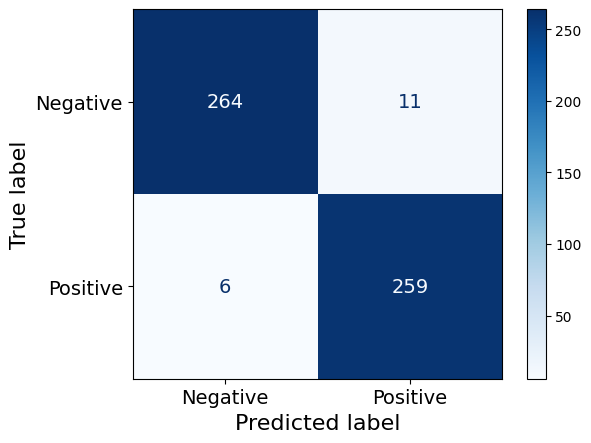

In [ ]:
import matplotlib.pyplot as plt
import numpy
from sklearn import metrics

preds_list_cm = [id2label[sentiment] for sentiment in preds_list]
references_ids_cm = [id2label[sentiment] for sentiment in references_ids]

confusion_matrix = metrics.confusion_matrix(references_ids_cm, preds_list_cm) # Compute the confusion matrix

cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels=['Negative','Positive'], ) # Create a ConfusionMatrixDisplay object

cm_display.plot(cmap='Blues', text_kw={'fontsize': 14})

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.xlabel('Predicted label', fontsize=16)
plt.ylabel('True label', fontsize=16)

plt.show() # Display the plot

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Import evaluation metrics
import numpy as np # Import numpy

print("Accuracy:",accuracy_score(preds_list_cm, references_ids_cm))
print("Precision:",precision_score(preds_list_cm, references_ids_cm, average='macro'))
print("Recall:",recall_score(preds_list_cm, references_ids_cm, average='macro'))
print("f1-score:",f1_score(preds_list_cm, references_ids_cm, average='macro'))

Accuracy: 0.9685185185185186
Precision: 0.9686792452830189
Recall: 0.9685185185185186
f1-score: 0.968515819257481


In [ ]:
df_test['preds_labels'] = preds_list
df_test

,text,labels,preds_labels
0,kualitas sesuai harga ??,1,1
1,"pembelian kedua, semoga sehat lagi kucingnya",1,1
2,Alhamdulillah sampai,1,1
3,Nyaman dipakai ?. Jamnya bagus banget. Warnany...,1,1
4,"Warnanya soft,baguus sukaaa harga terjangkau b...",1,1
...,...,...,...
535,"Respon seller sangat cepat dan ramah, packing ...",1,1
536,brg di trima dgn baik n respon cepat tks,1,1
537,"isinya cuma 800 gr, diskripsinya 1 kg.. udah t...",0,0
538,mantap berkualitas,1,1
